In [57]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import sys
import pickle

sys.path.append('/Users/nmehlman/Library/Mobile Documents/com~apple~CloudDocs/Desktop/CSCI 699/Project/poison-perf')
from utils.algorithms import RGD, PerfGD
from utils.experiment_setup import setup_1d_non_linear_experiment, setup_binary_classification, setup_non_convex_1d, setup_2d_non_linear_experiment
from poisoning.oracle import oracle_poison_function, RGD_update_estimator, PerfGD_update_estimator, classification_sampling_estimator, gaussian_sampling_estimator
from poisoning.white_box import white_box_poison_function
from utils.plotting import plot_results_1d, plot_results_2d

### Global Config

In [58]:
delta_vals = np.linspace(0.0, 2, 50)
epsilon = 0.5
poison_step_size = 0.1
norm = 'linf'
n_trials_per_delta = 10

# Non-linear Means

In [59]:
# Experiment setup
a0 = 1.0
a1 = 1.0

proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)
mu, sigma, D_theta, loss, theta_0, grad2_est, f_hat, info = setup_1d_non_linear_experiment(a0=a0, a1=a1, perfGD=True)

# Hyperparameters
n = 500
eta = 0.05
max_iter = 30
normalize_grad = True

## RGD

In [60]:
# Clean training
theta_clean_avg = []
loss_clean_avg = []
for trial in range(n_trials_per_delta):
    theta_clean, _, all_losses_clean = RGD(
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    proj_theta=proj_theta,
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    return_losses=True,
                    normalize_grad=normalize_grad
        )

    theta_clean_avg.append(theta_clean.item())
    loss_clean_avg.append(all_losses_clean[-1])
    
theta_clean = np.mean(theta_clean_avg)
loss_clean = np.mean(loss_clean_avg)

### Black Box Attack

In [61]:
# TODO

### White Box Attack

In [62]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                poison_function=white_box_poison_function,
                theta_update_estimator=RGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad,
                return_losses=True,
    )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned.item())
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-linear-means/RGD/non-linear-means_RGD_white_box.pkl', 'wb'))

100%|██████████| 50/50 [00:29<00:00,  1.72it/s]


### Oracle Attack

In [63]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = RGD(
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    proj_theta=proj_theta,
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    poison_function=oracle_poison_function,
                    theta_update_estimator=RGD_update_estimator,
                    sampling_estimator=gaussian_sampling_estimator,
                    sampling_estimator_kwargs={'mu': mu, 'sigma': sigma},
                    poison_steps=int(float(delta)//poison_step_size) + 1,
                    poison_step_size=poison_step_size,
                    epsilon=epsilon,
                    delta=delta,
                    return_losses=True,
                    norm=norm,
                    normalize_grad=normalize_grad
        )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned.item())
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-linear-means/RGD/non-linear-means_RGD_oracle.pkl', 'wb'))

100%|██████████| 50/50 [00:29<00:00,  1.69it/s]


### Plots

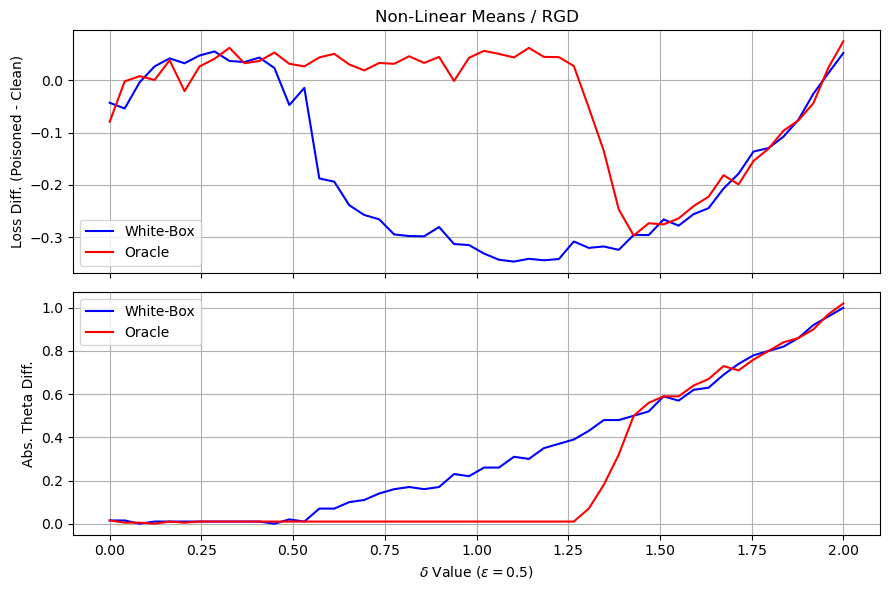

In [64]:
white_box_data = pickle.load(open('../exports/non-linear-means/RGD/non-linear-means_RGD_white_box.pkl', 'rb'))
oracle_data = pickle.load(open('../exports/non-linear-means/RGD/non-linear-means_RGD_oracle.pkl', 'rb'))
#black_box_data = pickle.load(open('exports/non-linear-means/RGD/non-linear-means_RGD_black_box.pkl', 'rb'))

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Top: loss difference
axes[0].plot(white_box_data["delta_vals"], white_box_data["loss_diff"], label="White-Box", color="blue")
axes[0].plot(oracle_data["delta_vals"], oracle_data["loss_diff"], label="Oracle", color="red")
#axes[0].plot(black_box_data["delta_vals"], black_box_data["loss_diff"], label="Black-Box", color="black")
axes[0].set_ylabel("Loss Diff. (Poisoned - Clean)")
axes[0].set_title("Non-Linear Means / RGD")
axes[0].legend()
axes[0].grid(True)

# Bottom: theta difference
axes[1].plot(white_box_data["delta_vals"], np.abs(white_box_data["theta_diff"]), label="White-Box", color="blue")
axes[1].plot(oracle_data["delta_vals"], np.abs(oracle_data["theta_diff"]), label="Oracle", color="red")
#axes[1].plot(black_box_data["delta_vals"], np.abs(black_box_data["theta_diff"]), label="Black-Box", color="black")
axes[1].set_ylabel("Abs. Theta Diff.")
axes[1].set_xlabel(r"$\delta$ Value ($\epsilon=0.5$)")

axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## PerfGD

In [65]:
# Clean training
theta_clean_avg = []
loss_clean_avg = []
for trial in range(n_trials_per_delta):
    theta_clean, _, all_losses_clean = PerfGD(
                    f_hat=f_hat,
                    grad2_est=grad2_est,
                    D_theta=D_theta,
                    loss=loss,
                    theta_0=theta_0.clone(),
                    proj_theta=proj_theta,
                    n=n,
                    eta=eta,
                    max_iter=max_iter,
                    return_losses=True,
                    normalize_grad=normalize_grad,
        )

    theta_clean_avg.append(theta_clean.item())
    loss_clean_avg.append(all_losses_clean[-1])
    
theta_clean = np.mean(theta_clean_avg)
loss_clean = np.mean(loss_clean_avg)

### Black Box Attack

In [66]:
# TODO

### White Box Attack

In [67]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=white_box_poison_function,
                theta_update_estimator=PerfGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size, 
                epsilon=epsilon,
                delta=delta,
                normalize_grad=normalize_grad
        )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned.item())
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-linear-means/PerfGD/non-linear-means_PerfGD_white_box.pkl', 'wb'))

100%|██████████| 50/50 [00:54<00:00,  1.09s/it]


### Oracle Attack

In [68]:
losses_poisoned, theta_poisoned = [], []

for delta in tqdm.tqdm(delta_vals):
    
    losses_poisoned_trial = []
    theta_poisoned_trial = []
    for trial in range(n_trials_per_delta):
    
        _theta_poisoned, _, all_losses_poisoned = PerfGD(
                f_hat=f_hat,
                grad2_est=grad2_est,
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=oracle_poison_function,
                theta_update_estimator=PerfGD_update_estimator,
                poison_steps=int(float(delta)//poison_step_size) + 1,
                poison_step_size=poison_step_size, 
                sampling_estimator=gaussian_sampling_estimator,
                sampling_estimator_kwargs={'mu': mu, 'sigma': sigma},
                epsilon=epsilon,
                delta=delta,
        )

        losses_poisoned_trial.append(all_losses_poisoned[-1])
        theta_poisoned_trial.append(_theta_poisoned.item())
        
    losses_poisoned.append(np.mean(losses_poisoned_trial))
    theta_poisoned.append(np.mean(theta_poisoned_trial))    
    
# Save results
loss_diff = np.array(losses_poisoned) - loss_clean
theta_diff = np.array(theta_poisoned) - theta_clean

results = {
    "loss_diff": loss_diff,
    "theta_diff": theta_diff,
    "delta_vals": delta_vals,
}

pickle.dump(results, open(f'../exports/non-linear-means/PerfGD/non-linear-means_PerfGD_oracle.pkl', 'wb'))

100%|██████████| 50/50 [00:53<00:00,  1.08s/it]


### Plots

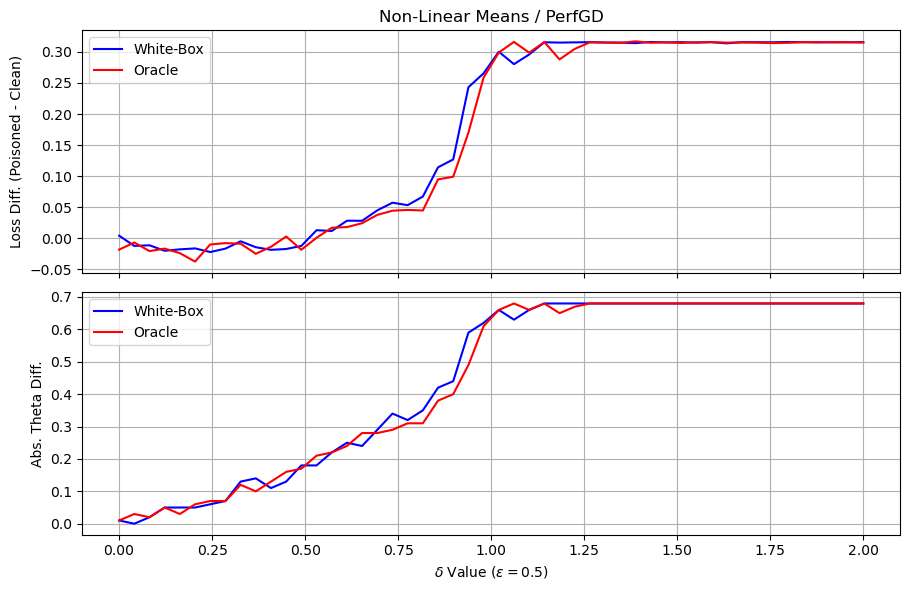

In [69]:
white_box_data = pickle.load(open('../exports/non-linear-means/PerfGD/non-linear-means_PerfGD_white_box.pkl', 'rb'))
oracle_data = pickle.load(open('../exports/non-linear-means/PerfGD/non-linear-means_PerfGD_oracle.pkl', 'rb'))
#black_box_data = pickle.load(open('exports/non-linear-means/PerfGD/non-linear-means_PerfGD_black_box.pkl', 'rb'))

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Top: loss difference
axes[0].plot(white_box_data["delta_vals"], white_box_data["loss_diff"], label="White-Box", color="blue")
axes[0].plot(oracle_data["delta_vals"], oracle_data["loss_diff"], label="Oracle", color="red")
#axes[0].plot(black_box_data["delta_vals"], black_box_data["loss_diff"], label="Black-Box", color="black")
axes[0].set_ylabel("Loss Diff. (Poisoned - Clean)")
axes[0].set_title("Non-Linear Means / PerfGD")
axes[0].legend()
axes[0].grid(True)

# Bottom: theta difference
axes[1].plot(white_box_data["delta_vals"], np.abs(white_box_data["theta_diff"]), label="White-Box", color="blue")
axes[1].plot(oracle_data["delta_vals"], np.abs(oracle_data["theta_diff"]), label="Oracle", color="red")
#axes[1].plot(black_box_data["delta_vals"], np.abs(black_box_data["theta_diff"]), label="Black-Box", color="black")
axes[1].set_ylabel("Abs. Theta Diff.")
axes[1].set_xlabel(r"$\delta$ Value ($\epsilon=0.5$)")

axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()